In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

In [2]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature count:", X.shape[1])
print("Target names:", cancer.target_names)

X shape: (569, 30)
y shape: (569,)
Feature count: 30
Target names: ['malignant' 'benign']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data mean:", X_train_scaled.mean().round(4))
print("Scaled training data std:", X_train_scaled.std().round(4))

Scaled training data mean: -0.0
Scaled training data std: 1.0


In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
n_features = X_train_scaled.shape[1]

w = np.random.normal(loc=0.0, scale=0.01, size=n_features)
b = np.random.normal(loc=0.0, scale=0.01)

print("w shape:", w.shape)
print("b:", b)

w shape: (30,)
b: -0.006017066122293969


In [7]:
def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

In [8]:
first_5_test_rows = X_test_scaled[:5]

predicted_probabilities = forward(first_5_test_rows, w, b)

print("Predicted probabilities for first 5 test rows:")
print(predicted_probabilities)

Predicted probabilities for first 5 test rows:
[0.49622457 0.51754028 0.50708005 0.48744002 0.48394608]


In machine-learning terms, this is a single-neuron binary classifier, equivalent to logistic regression, because it computes a weighted sum of the input features and passes it through a sigmoid function to output a probability.

In [9]:
def relu(z):
    return np.maximum(0, z)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [10]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        # He initialization for hidden layer
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        
        # He initialization for output layer
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))
    
    def forward(self, X):
        # First layer: linear transformation
        self.z1 = np.dot(X, self.W1) + self.b1
        
        # Hidden activation: ReLU
        self.a1 = relu(self.z1)
        
        # Output layer: linear transformation
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        
        # Output activation: sigmoid
        self.a2 = sigmoid(self.z2)
        
        return self.a2

In [11]:
mlp = NumpyMLP(
    input_size=30,
    hidden_size=8,
    output_size=1
)

print("W1 shape:", mlp.W1.shape)
print("b1 shape:", mlp.b1.shape)
print("W2 shape:", mlp.W2.shape)
print("b2 shape:", mlp.b2.shape)

W1 shape: (30, 8)
b1 shape: (1, 8)
W2 shape: (8, 1)
b2 shape: (1, 1)


In [12]:
test_predictions = mlp.forward(X_test_scaled)

print("Output shape:", test_predictions.shape)
print("First 5 predictions:")
print(test_predictions[:5])

Output shape: (114, 1)
First 5 predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]


In [13]:
predictions_df = pd.DataFrame({
    "Actual Label": y_test[:5],
    "Predicted Probability of Class 1": test_predictions[:5].flatten()
})

display(predictions_df)

,Actual Label,Predicted Probability of Class 1
0,1,0.520733
1,0,0.125625
2,0,0.547428
3,1,0.426735
4,1,0.440826


A two-layer MLP was implemented in NumPy with 30 input features, 8 hidden neurons, and 1 output neuron. The hidden layer used ReLU, and the output layer used sigmoid to produce a probability for binary classification.

The output shape is `(N, 1)` because the model produces one probability for each input sample. This is the correct shape for binary classification, where each row needs one predicted probability for class `1`. The model has not been trained yet, so the output values have the correct shape but are not meaningful predictions yet.

In [14]:
class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
    
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out

In [15]:
torch_model = TorchMLP()

print(torch_model)

TorchMLP(
  (fc1): Linear(in_features=30, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [16]:
with torch.no_grad():
    torch_model.fc1.weight.data = torch.from_numpy(mlp.W1.T).float()
    torch_model.fc1.bias.data = torch.from_numpy(mlp.b1.flatten()).float()
    
    torch_model.fc2.weight.data = torch.from_numpy(mlp.W2.T).float()
    torch_model.fc2.bias.data = torch.from_numpy(mlp.b2.flatten()).float()

In [17]:
X_test_tensor = torch.from_numpy(X_test_scaled).float()

print("X_test_tensor shape:", X_test_tensor.shape)

X_test_tensor shape: torch.Size([114, 30])


In [18]:
torch_model.eval()

with torch.no_grad():
    torch_predictions = torch_model(X_test_tensor)

print("Torch output shape:", torch_predictions.shape)
print("First 5 Torch predictions:")
print(torch_predictions[:5])

Torch output shape: torch.Size([114, 1])
First 5 Torch predictions:
tensor([[0.5207],
        [0.1256],
        [0.5474],
        [0.4267],
        [0.4408]])


In [19]:
torch_predictions_np = torch_predictions.numpy()

max_abs_difference = np.max(
    np.abs(test_predictions - torch_predictions_np)
)

print("Maximum absolute difference:", max_abs_difference)

Maximum absolute difference: 7.833688780989334e-08


In [20]:
comparison_df = pd.DataFrame({
    "NumPy Prediction": test_predictions[:5].flatten(),
    "PyTorch Prediction": torch_predictions_np[:5].flatten(),
    "Absolute Difference": np.abs(
        test_predictions[:5].flatten() - torch_predictions_np[:5].flatten()
    )
})

display(comparison_df)

,NumPy Prediction,PyTorch Prediction,Absolute Difference
0,0.520733,0.520733,1.704340e-08
1,0.125625,0.125625,5.412891e-08
2,0.547428,0.547428,3.735900e-09
3,0.426735,0.426735,3.143349e-08
4,0.440826,0.440826,2.652903e-08


The same MLP architecture from Task 2 was recreated in PyTorch using `nn.Module`. The model used 30 input features, 8 hidden neurons with ReLU activation, and 1 sigmoid output.

The NumPy weights and biases were manually copied into the PyTorch model. Since PyTorch stores `nn.Linear` weights as `(out_features, in_features)`, the NumPy weight matrices were transposed before copying.

The maximum absolute difference between the NumPy and PyTorch outputs was `7.83e-08`, which is extremely small. This confirms that both networks produced numerically identical predictions for the same inputs and weights.

In [21]:
class ActivationMLP(nn.Module):
    def __init__(self, activation_name):
        super().__init__()
        
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.activation_name = activation_name
        
        if activation_name == "sigmoid":
            self.activation = torch.sigmoid
        elif activation_name == "tanh":
            self.activation = torch.tanh
        elif activation_name == "relu":
            self.activation = torch.relu
        else:
            raise ValueError("activation_name must be 'sigmoid', 'tanh', or 'relu'")
    
    def forward(self, x):
        z1 = self.fc1(x)              # hidden pre-activation
        h = self.activation(z1)       # hidden post-activation
        z2 = self.fc2(h)
        out = torch.sigmoid(z2)       # binary output probability
        
        return out, z1, h

In [22]:
activation_models = {
    "Sigmoid": ActivationMLP("sigmoid"),
    "Tanh": ActivationMLP("tanh"),
    "ReLU": ActivationMLP("relu")
}

for name, model in activation_models.items():
    print(name)
    print(model)
    print()

Sigmoid
ActivationMLP(
  (fc1): Linear(in_features=30, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

Tanh
ActivationMLP(
  (fc1): Linear(in_features=30, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

ReLU
ActivationMLP(
  (fc1): Linear(in_features=30, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)



In [23]:
X_test_tensor = torch.from_numpy(X_test_scaled).float()

In [24]:
activation_results = {}

for name, model in activation_models.items():
    model.eval()
    
    with torch.no_grad():
        output, z1, h = model(X_test_tensor)
    
    activation_results[name] = {
        "output": output.numpy(),
        "pre_activation": z1.numpy(),
        "post_activation": h.numpy()
    }
    
    print(f"{name} output shape:", output.shape)
    print(f"{name} first 5 predictions:")
    print(output[:5].numpy().flatten())
    print()

Sigmoid output shape: torch.Size([114, 1])
Sigmoid first 5 predictions:
[0.36246035 0.33939606 0.34773397 0.3734585  0.37381157]

Tanh output shape: torch.Size([114, 1])
Tanh first 5 predictions:
[0.5430905  0.4551646  0.4614681  0.57783055 0.577041  ]

ReLU output shape: torch.Size([114, 1])
ReLU first 5 predictions:
[0.44765458 0.3326106  0.4122662  0.42267933 0.4527632 ]



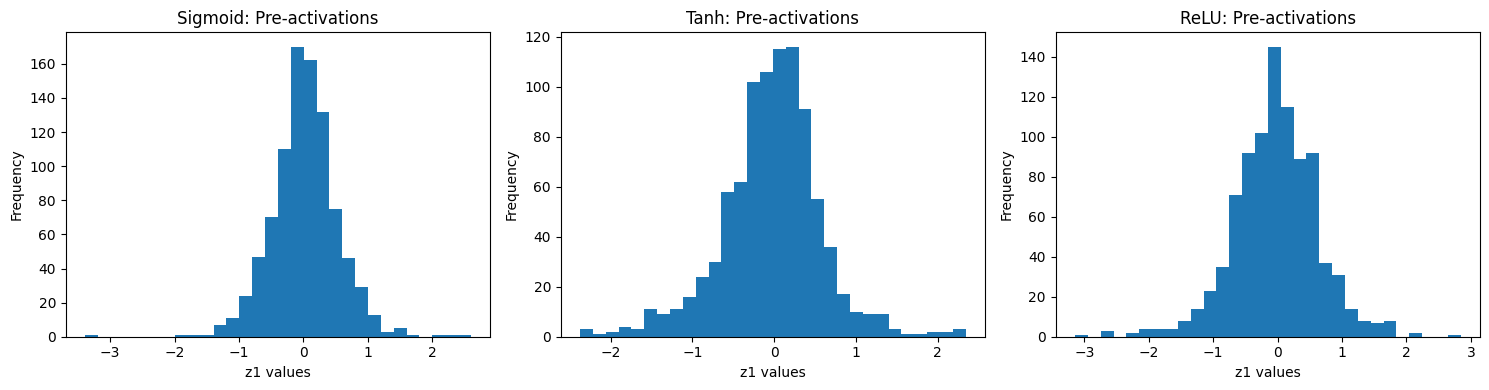

In [25]:
plt.figure(figsize=(15, 4))

for i, (name, results) in enumerate(activation_results.items(), 1):
    pre_activation_values = results["pre_activation"].flatten()
    
    plt.subplot(1, 3, i)
    plt.hist(pre_activation_values, bins=30)
    plt.title(f"{name}: Pre-activations")
    plt.xlabel("z1 values")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

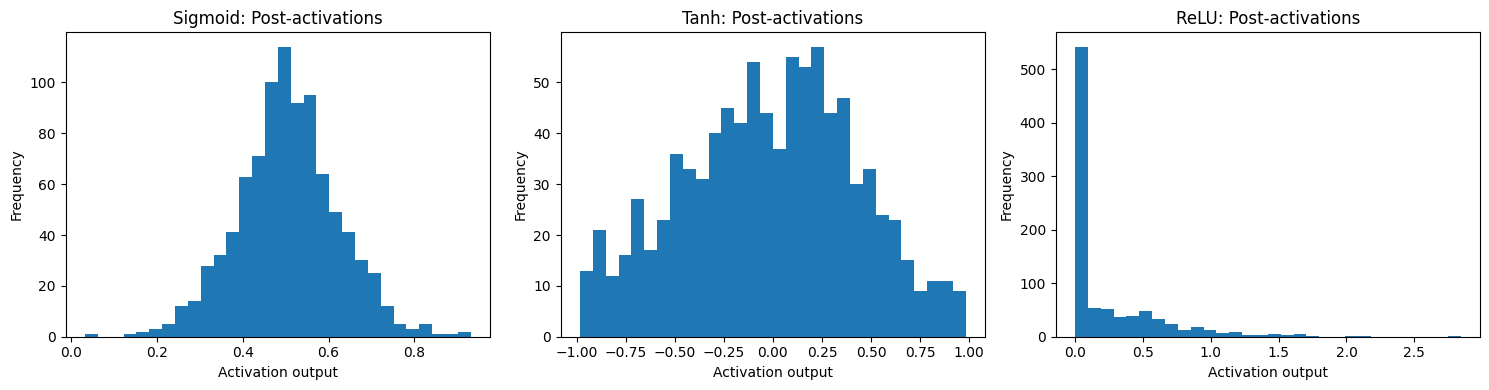

In [26]:
plt.figure(figsize=(15, 4))

for i, (name, results) in enumerate(activation_results.items(), 1):
    post_activation_values = results["post_activation"].flatten()
    
    plt.subplot(1, 3, i)
    plt.hist(post_activation_values, bins=30)
    plt.title(f"{name}: Post-activations")
    plt.xlabel("Activation output")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [27]:
summary_rows = []

for name, results in activation_results.items():
    h = results["post_activation"].flatten()
    
    if name == "Sigmoid":
        saturated = np.mean((h < 0.05) | (h > 0.95))
        summary_rows.append({
            "Activation": name,
            "Measurement": "Fraction close to 0 or 1",
            "Fraction": saturated
        })
    
    elif name == "Tanh":
        saturated = np.mean((h < -0.95) | (h > 0.95))
        summary_rows.append({
            "Activation": name,
            "Measurement": "Fraction close to -1 or 1",
            "Fraction": saturated
        })
    
    elif name == "ReLU":
        inactive = np.mean(h == 0)
        summary_rows.append({
            "Activation": name,
            "Measurement": "Fraction exactly 0",
            "Fraction": inactive
        })

activation_summary_df = pd.DataFrame(summary_rows)

display(activation_summary_df)

,Activation,Measurement,Fraction
0,Sigmoid,Fraction close to 0 or 1,0.001096
1,Tanh,Fraction close to -1 or 1,0.017544
2,ReLU,Fraction exactly 0,0.516447


Three PyTorch MLP variants were tested with the same architecture but different hidden activations: Sigmoid, Tanh, and ReLU.

For Sigmoid, only about `0.11%` of post-activation values were close to `0` or `1`, so very few units were saturated. For Tanh, about `1.75%` of values were close to `-1` or `1`, so saturation was also low. For ReLU, about `51.64%` of outputs were exactly `0`, meaning around half of the hidden units were inactive for this batch.

ReLU is often a better default for hidden layers because positive values are not squeezed into a small range like Sigmoid or Tanh. This helps gradients flow more easily during training. Even though many ReLU outputs can be zero, the active units can still pass strong signals forward.